# Motivation to Derivatives — Part I

This opening lesson introduces the ideas that will be studied in Week 1 and explains why derivatives and optimization matter in machine learning.

## Welcome to Week 1

This week begins with the intuition behind a **derivative**. The first example will use velocity and a speedometer.

The course will then look at familiar mathematical functions:

- constant functions
- linear functions
- quadratics
- polynomials
- exponential functions
- logarithmic functions

You will learn how to find their derivatives and how to work with more complicated functions using:

- the sum rule
- the product rule
- the chain rule
- multiplication by scalars

## Why calculus matters in machine learning

Derivatives are useful for **optimization**: finding the maximum or minimum value of a function.

This is important in machine learning because training a model means finding the model that fits the available data as well as possible. A loss function measures how well the model is doing, and training tries to minimize that loss.

Later lessons will include:

- an example involving temperature
- square loss
- log loss

## Predicting the price of a house

Consider houses with different numbers of bedrooms:

- a one-bedroom house costs **\$150,000**;
- a two-bedroom house costs **\$250,000**;
- the price of a nine-bedroom house is unknown.

The complete example also has prices for houses with 3, 5, 6, 7, 8, and 10 bedrooms. Those prices appear in the lecture's table but are not stated in the transcript, so they are not recreated here.

The goal is to use the known house data to predict the price of the nine-bedroom house.

### Plotting the house data

The horizontal axis represents the number of bedrooms, and the vertical axis represents the house price. Each house is shown as a dot.

The plot below is intentionally schematic because the transcript does not provide every price from the lecture slide. It shows the two stated prices, an illustrative starting line, and a line consistent with the stated prediction of **\$950,000** for nine bedrooms.

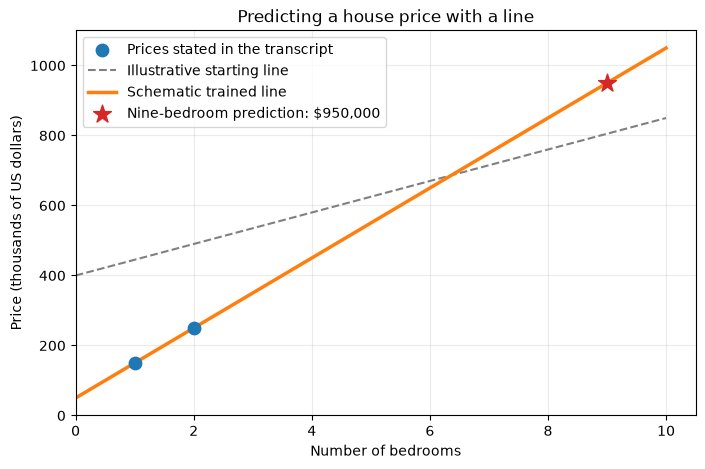

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

known_bedrooms: np.ndarray = np.array([1.0, 2.0])
known_prices: np.ndarray = np.array([150.0, 250.0])
bedroom_range: np.ndarray = np.linspace(0.0, 10.0, 200)
starting_line: np.ndarray = 45.0 * bedroom_range + 400.0
trained_line: np.ndarray = 100.0 * bedroom_range + 50.0

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    known_bedrooms,
    known_prices,
    color="tab:blue",
    s=80,
    label="Prices stated in the transcript",
    zorder=3,
)
ax.plot(
    bedroom_range,
    starting_line,
    color="gray",
    linestyle="--",
    label="Illustrative starting line",
)
ax.plot(
    bedroom_range,
    trained_line,
    color="tab:orange",
    linewidth=2.5,
    label="Schematic trained line",
)
ax.scatter(
    9,
    950,
    color="tab:red",
    marker="*",
    s=180,
    label="Nine-bedroom prediction: $950,000",
    zorder=4,
)
ax.set(
    xlabel="Number of bedrooms",
    ylabel="Price (thousands of US dollars)",
    title="Predicting a house price with a line",
    xlim=(0, 10.5),
    ylim=(0, 1100),
)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

### Model training

The machine learning model takes in the known data and begins **model training**.

The lecture compares model training to the engine of a car: it is the important process under the hood of an AI experiment. The model starts with an arbitrary line and adjusts it, looking for a line that goes as close as possible to the known points.

Once training is complete, the model predicts that the nine-bedroom house costs **\$950,000**.

Because the model predicts a numerical value using a line, this is a **linear regression** problem.

## Classifying alien sentiment

Imagine traveling to a distant planet and meeting alien life. You do not need to learn the entire alien language. You only want to predict whether an alien is happy or sad.

The available examples are:

| Sentence | ACK count | BEEP count | Mood |
|---|---:|---:|---|
| `ACK ACK ACK` | 3 | 0 | Happy |
| `BEEP BEEP` | 0 | 2 | Sad |
| `ACK BEEP ACK` | 2 | 1 | Happy |
| `ACK BEEP BEEP BEEP` | 1 | 3 | Sad |

For each sentence, the model records how many times **ACK** and **BEEP** appear. Because the goal is to choose between happy and sad, this is a **classification** problem. More specifically, it is a simple sentiment analysis model.

### Training a classification model

The horizontal axis now represents the number of ACKs, and the vertical axis represents the number of BEEPs.

The model is again a line, but this time the line is used to split the happy points from the sad points. Training moves from a poor line to a better line and finally to a line that separates the four examples.

The exact lines shown in the lecture are not specified in the transcript, so the progression below is schematic.

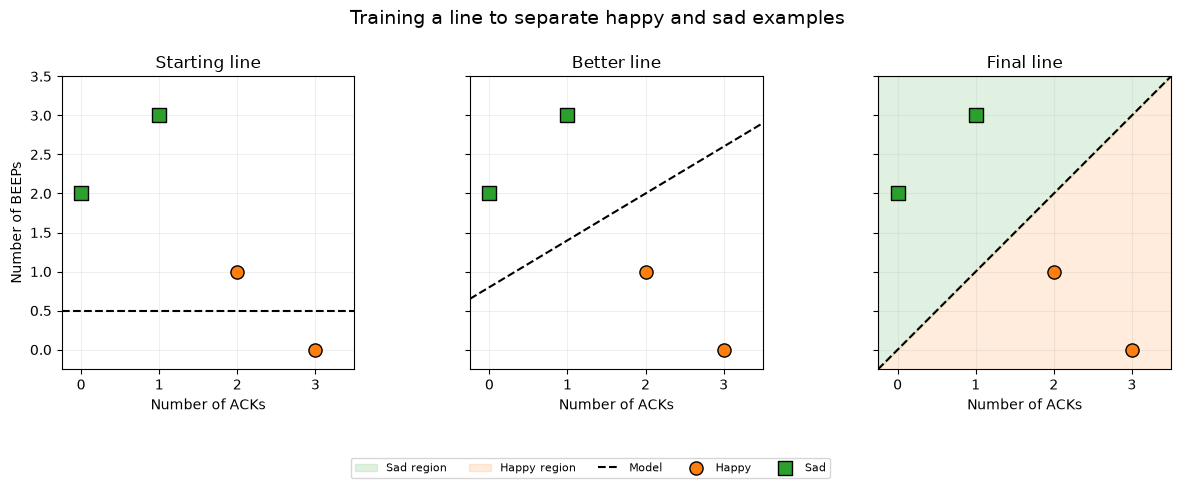

In [2]:
ack_counts: np.ndarray = np.array([3.0, 0.0, 2.0, 1.0])
beep_counts: np.ndarray = np.array([0.0, 2.0, 1.0, 3.0])
moods: np.ndarray = np.array(["Happy", "Sad", "Happy", "Sad"])
axis_values: np.ndarray = np.linspace(-0.25, 3.5, 200)
boundaries: list[tuple[str, float, float]] = [
    ("Starting line", 0.0, 0.5),
    ("Better line", 0.6, 0.8),
    ("Final line", 1.0, 0.0),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)
for panel, (title, slope, intercept) in enumerate(boundaries):
    ax = axes[panel]
    boundary: np.ndarray = slope * axis_values + intercept

    if panel == 2:
        ax.fill_between(
            axis_values,
            boundary,
            3.5,
            color="tab:green",
            alpha=0.14,
            label="Sad region",
        )
        ax.fill_between(
            axis_values,
            -0.25,
            boundary,
            color="tab:orange",
            alpha=0.14,
            label="Happy region",
        )

    ax.plot(axis_values, boundary, color="black", linestyle="--", label="Model")

    for mood, color, marker in [
        ("Happy", "tab:orange", "o"),
        ("Sad", "tab:green", "s"),
    ]:
        selected: np.ndarray = moods == mood
        ax.scatter(
            ack_counts[selected],
            beep_counts[selected],
            color=color,
            marker=marker,
            edgecolor="black",
            s=90,
            label=mood,
            zorder=3,
        )

    ax.set(
        xlabel="Number of ACKs",
        title=title,
        xlim=(-0.25, 3.5),
        ylim=(-0.25, 3.5),
    )
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Number of BEEPs")
handles, labels = axes[2].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=5, fontsize=8)
fig.suptitle("Training a line to separate happy and sad examples", fontsize=14)
fig.subplots_adjust(bottom=0.23, top=0.84, wspace=0.18)
plt.show()

The final line splits the plane into two regions:

- the **sad** region is shown in green;
- the **happy** region is shown in orange.

When a new sentence arrives, the model counts its ACKs and BEEPs. The region containing that new point determines the predicted mood.

The model may make mistakes, but based on these examples it should often make a useful prediction.

## Mathematics under the hood

How does a model learn a useful line? Mathematics drives the training process. Important ideas include:

- gradients
- derivatives
- optimization
- loss and cost functions
- gradient descent

This course will explain how these ideas work at the core of model training.

The house and alien examples introduce linear regression and classification, but the same mathematical ideas apply to many other machine learning algorithms, including neural networks.

### Video 1 takeaway

This introductory lesson presents the main motivation for derivatives:

- derivatives help with optimization;
- optimization helps minimize a model's loss;
- minimizing loss is a central part of model training;
- the same training idea appears in regression, classification, and more complex models.

The next lessons begin developing the derivative concepts needed to understand this process.

## Video 2 — Derivatives and velocity

### Average velocity and instantaneous velocity

Imagine traveling 100 kilometers in one hour. Your **average velocity** is 100 kilometers per hour.

That does not mean the car moved at the same velocity for the entire hour. You may have started fast, slowed down, stopped, sped up, or even gone in reverse.

The velocity at one particular moment is called **instantaneous velocity**. This gives the central intuition for a derivative:

> A derivative is the instantaneous rate of change of a function.

In this example, the changing function is distance, and its derivative is velocity.

### A broken speedometer

Suppose you are driving on a straight road. Your speedometer breaks, but an app still records the distance you have traveled.

You drive for one minute and record the distance every five seconds. The full table is shown in the lecture but is not completely included in the transcript, so this notebook uses only the stated values.

Average velocity is the distance traveled divided by the time elapsed:

$$
\text{average velocity}
=
\frac{\text{change in distance}}{\text{change in time}}.
$$

On a distance-versus-time graph:

- $\Delta t$ is the horizontal change in time;
- $\Delta x$ is the vertical change in distance.

Therefore, average velocity is also the slope of the line between two measurements:

$$
\text{average velocity}
=
\text{slope}
=
\frac{\Delta x}{\Delta t}.
$$

### Quiz 1: Is the car moving at constant speed?

No.

From 10 to 15 seconds, the car travels 80 meters during a 5-second interval:

$$
\frac{80\ \text{m}}{5\ \text{s}}=16\ \text{m/s}.
$$

From 15 to 20 seconds, it travels 63 meters during another 5-second interval:

$$
\frac{63\ \text{m}}{5\ \text{s}}=12.6\ \text{m/s}.
$$

The time intervals have the same length, but their average velocities are different. The car is therefore not moving at constant speed.

### Quiz 2: Can we find the exact velocity at 12.5 seconds?

No. The five-second measurements tell us what happened between 10 and 15 seconds as a whole, but not what happened at every instant inside that interval.

The slope

$$
\frac{\Delta x}{\Delta t}
$$

gives the **average** velocity across the interval. At 12.5 seconds, the car may have been moving faster or slower than that average. We can calculate an estimate, but not the exact instantaneous velocity from the given table.

### Average velocity from 10 to 15 seconds

At 10 seconds, the car has traveled 122 meters. At 15 seconds, it has traveled 202 meters.

The horizontal change is the elapsed time:

$$
\Delta t = 15-10 = 5\ \text{s}.
$$

The vertical change is the distance traveled:

$$
\Delta x = 202-122 = 80\ \text{m}.
$$

The slope is therefore

$$
\frac{\Delta x}{\Delta t}
=
\frac{202-122}{15-10}
=
\frac{80}{5}
=
16\ \text{m/s}.
$$

This slope is the average velocity from 10 to 15 seconds and a reasonable estimate of the velocity at 12.5 seconds.

### A better estimate from finer measurements

Now suppose the app records distance every second. Near 12.5 seconds, the transcript gives:

| Time | Distance traveled |
|---:|---:|
| 12 seconds | 155 meters |
| 13 seconds | 170 meters |

For this smaller interval:

$$
\Delta t = 13-12 = 1\ \text{s}
$$

and

$$
\Delta x = 170-155 = 15\ \text{m}.
$$

The new slope is

$$
\frac{\Delta x}{\Delta t}
=
\frac{170-155}{13-12}
=
15\ \text{m/s}.
$$

Because the interval from 12 to 13 seconds is much closer to 12.5 seconds, this is a better estimate than the five-second interval.

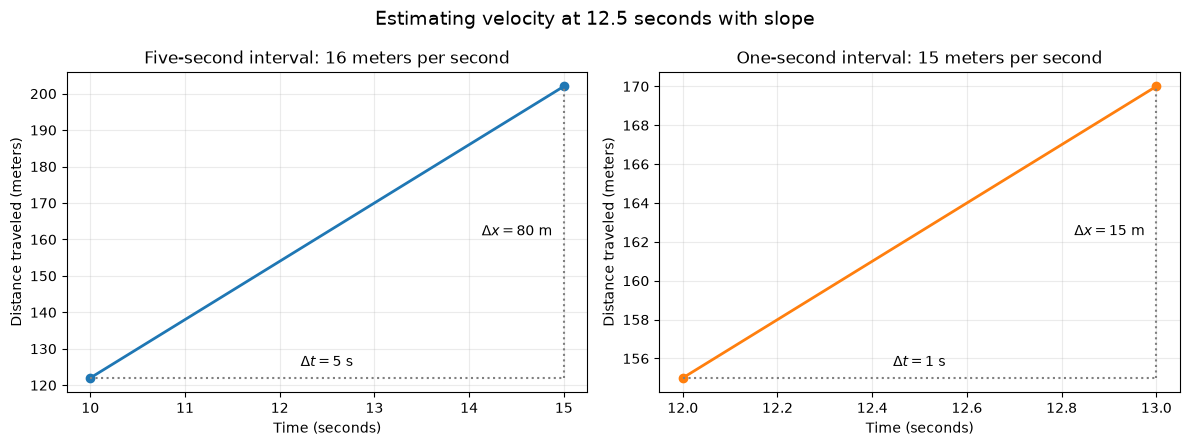

In [3]:
wide_times: np.ndarray = np.array([10.0, 15.0])
wide_distances: np.ndarray = np.array([122.0, 202.0])
narrow_times: np.ndarray = np.array([12.0, 13.0])
narrow_distances: np.ndarray = np.array([155.0, 170.0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(wide_times, wide_distances, color="tab:blue", marker="o", linewidth=2)
axes[0].plot([10, 15], [122, 122], color="gray", linestyle=":")
axes[0].plot([15, 15], [122, 202], color="gray", linestyle=":")
axes[0].annotate(r"$\Delta t=5$ s", (12.5, 122), xytext=(0, 8), textcoords="offset points",
                 ha="center")
axes[0].annotate(r"$\Delta x=80$ m", (15, 162), xytext=(-8, 0), textcoords="offset points",
                 ha="right", va="center")
axes[0].set(
    xlabel="Time (seconds)",
    ylabel="Distance traveled (meters)",
    title="Five-second interval: 16 meters per second",
)
axes[0].grid(alpha=0.25)

axes[1].plot(narrow_times, narrow_distances, color="tab:orange", marker="o", linewidth=2)
axes[1].plot([12, 13], [155, 155], color="gray", linestyle=":")
axes[1].plot([13, 13], [155, 170], color="gray", linestyle=":")
axes[1].annotate(r"$\Delta t=1$ s", (12.5, 155), xytext=(0, 8), textcoords="offset points",
                 ha="center")
axes[1].annotate(r"$\Delta x=15$ m", (13, 162.5), xytext=(-8, 0), textcoords="offset points",
                 ha="right", va="center")
axes[1].set(
    xlabel="Time (seconds)",
    ylabel="Distance traveled (meters)",
    title="One-second interval: 15 meters per second",
)
axes[1].grid(alpha=0.25)

fig.suptitle("Estimating velocity at 12.5 seconds with slope", fontsize=14)
fig.tight_layout()
plt.show()

### From estimates to the derivative

The one-second interval gives a better estimate, but it still does not provide the exact velocity at 12.5 seconds.

To improve the estimate, use measurements from finer and finer time intervals around that instant. As $\Delta t$ becomes smaller, the interval's average velocity becomes a better estimate of the instantaneous velocity.

This is the idea that leads from the slope

$$
\frac{\Delta x}{\Delta t}
$$

to the derivative of distance with respect to time. The next lesson develops that step.

## Video 3 — Instantaneous velocity and the tangent line

In the previous video, average velocity over a time interval was calculated as

$$
\frac{\Delta x}{\Delta t},
$$

where $\Delta x$ is the change in distance and $\Delta t$ is the change in time.

Now return to $t=12.5$ seconds. The goal is to estimate the velocity at that particular instant.

### Moving the second point closer

Start at the point on the distance curve where $t=12.5$. Choose a second point to its right.

The line joining the two points is a **secant line**. Its slope,

$$
\frac{\Delta x}{\Delta t},
$$

is the average velocity over that interval—not yet the instantaneous velocity at 12.5 seconds.

Move the second point closer to 12.5. The time interval $\Delta t$ becomes smaller, and the secant line gives a more local estimate. Continue moving the point closer and closer.

### From secant lines to a tangent line

The following plot illustrates the process. The exact distance curve is not provided in the transcript, so the smooth curve is an explicitly illustrative one that passes through the stated measurements at 12 and 13 seconds.

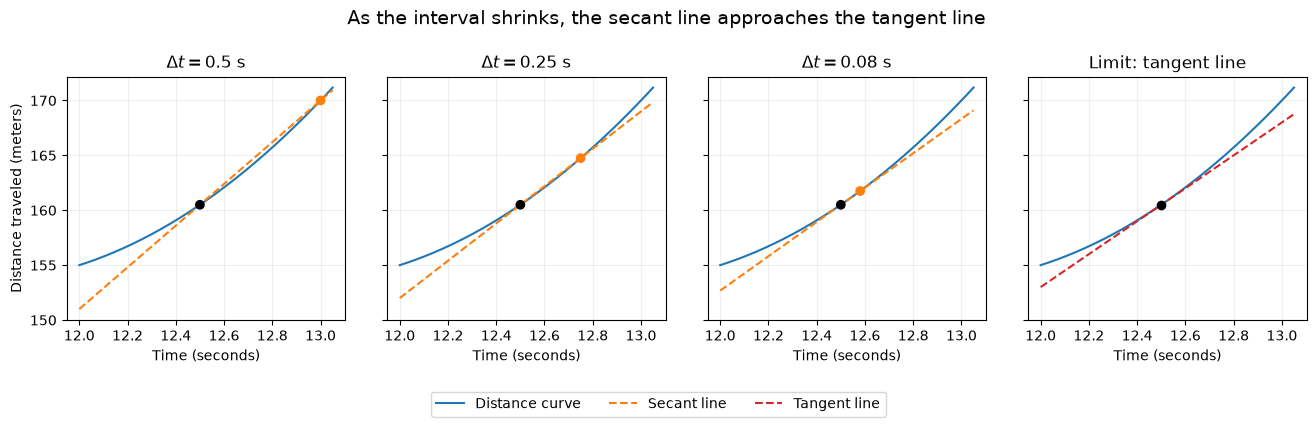

In [4]:
def illustrative_distance(time_s: np.ndarray) -> np.ndarray:
    """Return a smooth illustrative distance curve near 12.5 seconds."""
    centered_time: np.ndarray = time_s - 12.5
    return 162.5 + 15.0 * centered_time + 8.0 * (centered_time**2 - 0.25)


time_values: np.ndarray = np.linspace(12.0, 13.05, 300)
distance_values: np.ndarray = illustrative_distance(time_values)
center_time: float = 12.5
center_distance: float = float(illustrative_distance(np.array([center_time]))[0])
intervals: list[float] = [0.5, 0.25, 0.08]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), sharex=True, sharey=True)
for panel, interval in enumerate(intervals):
    second_time: float = center_time + interval
    second_distance: float = float(illustrative_distance(np.array([second_time]))[0])
    secant_slope: float = (second_distance - center_distance) / interval
    secant_line: np.ndarray = center_distance + secant_slope * (time_values - center_time)

    axes[panel].plot(time_values, distance_values, color="tab:blue", label="Distance curve")
    axes[panel].plot(time_values, secant_line, color="tab:orange", linestyle="--",
                     label="Secant line")
    axes[panel].scatter([center_time, second_time], [center_distance, second_distance],
                        color=["black", "tab:orange"], zorder=3)
    axes[panel].set_title(rf"$\Delta t={interval:g}$ s")

illustrative_tangent_slope: float = 15.0
tangent_line: np.ndarray = center_distance + illustrative_tangent_slope * (
    time_values - center_time
)
axes[3].plot(time_values, distance_values, color="tab:blue", label="Distance curve")
axes[3].plot(time_values, tangent_line, color="tab:red", linestyle="--",
             label="Tangent line")
axes[3].scatter([center_time], [center_distance], color="black", zorder=3)
axes[3].set_title("Limit: tangent line")

for ax in axes:
    ax.set_xlabel("Time (seconds)")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Distance traveled (meters)")

fig.legend(
    [axes[0].lines[0], axes[0].lines[1], axes[3].lines[1]],
    ["Distance curve", "Secant line", "Tangent line"],
    loc="outside lower center",
    ncol=3,
)
fig.suptitle("As the interval shrinks, the secant line approaches the tangent line", fontsize=14)
fig.subplots_adjust(bottom=0.24, top=0.82, wspace=0.15)
plt.show()

### The derivative

Imagine moving the second point so close to $t=12.5$ that the interval approaches zero. The secant line approaches the **tangent line** at that point.

This limiting slope is written as

$$
\lim_{\Delta t\to 0}\frac{\Delta x}{\Delta t}
=
\frac{dx}{dt}.
$$

The quantity $\frac{dx}{dt}$ is the instantaneous rate at which distance changes with time. It is the instantaneous velocity and the **derivative** of distance with respect to time.

More generally:

> The derivative of a function at a point is the slope of the tangent line at that point.

## Video 4 — Horizontal tangents and zero velocity

Now that the derivative has been introduced as instantaneous velocity, consider an important property: when distance is not changing, the velocity is zero.

Return to the measurements between 19 and 20 seconds:

| Time | Distance |
|---:|---:|
| 19 seconds | 265 meters |
| 20 seconds | 265 meters |

The distance is the same at both times. The car could have moved and returned, but the lecture asks us to assume that it remained still during this interval.

### A horizontal line has slope zero

The change in distance is

$$
\Delta x = 265-265 = 0\ \text{m},
$$

and the change in time is

$$
\Delta t = 20-19 = 1\ \text{s}.
$$

Therefore,

$$
\text{slope}
=
\frac{\Delta x}{\Delta t}
=
\frac{265-265}{20-19}
=
\frac{0}{1}
=
0\ \text{m/s}.
$$

There is no vertical rise in the graph, so the line is horizontal and the car's velocity is zero.

### Quiz: Where is the velocity zero?

The lecture next considers a trajectory in which the car repeatedly moves forward, stops, moves backward, and moves forward again.

The exact trajectory values and times are not stated in the transcript. The right-hand plot below is therefore schematic. It preserves the two important features given in the lesson:

- there are five marked points where the car is stopped;
- the highest distance shown is 50 meters.

At each stopping point, the tangent line is horizontal. A horizontal tangent has slope zero, so the derivative—and therefore the instantaneous velocity—is zero.

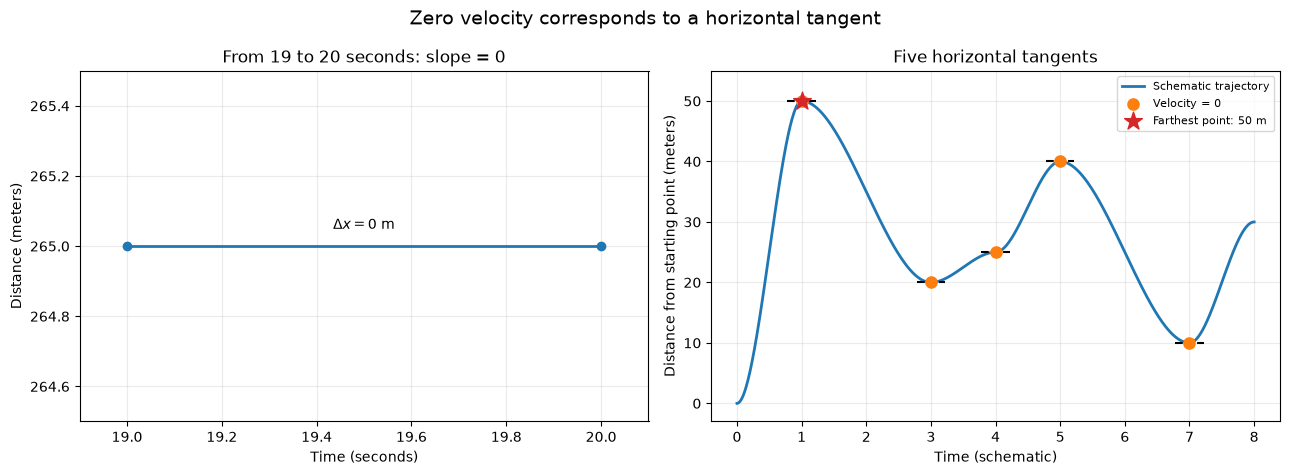

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Exact interval stated in the transcript.
stop_times: np.ndarray = np.array([19.0, 20.0])
stop_distances: np.ndarray = np.array([265.0, 265.0])
axes[0].plot(stop_times, stop_distances, color="tab:blue", marker="o", linewidth=2)
axes[0].set(
    xlabel="Time (seconds)",
    ylabel="Distance (meters)",
    title="From 19 to 20 seconds: slope = 0",
    xlim=(18.9, 20.1),
    ylim=(264.5, 265.5),
)
axes[0].annotate(r"$\Delta x=0$ m", (19.5, 265), xytext=(0, 12),
                 textcoords="offset points", ha="center")
axes[0].grid(alpha=0.25)

# Schematic trajectory: smooth transitions with five interior horizontal tangents.
control_times: np.ndarray = np.array([0.0, 1.0, 3.0, 4.0, 5.0, 7.0, 8.0])
control_distances: np.ndarray = np.array([0.0, 50.0, 20.0, 25.0, 40.0, 10.0, 30.0])
trajectory_times: list[np.ndarray] = []
trajectory_distances: list[np.ndarray] = []

for start in range(len(control_times) - 1):
    segment_time: np.ndarray = np.linspace(
        control_times[start],
        control_times[start + 1],
        100,
        endpoint=start == len(control_times) - 2,
    )
    fraction: np.ndarray = (
        (segment_time - control_times[start])
        / (control_times[start + 1] - control_times[start])
    )
    smooth_fraction: np.ndarray = 3.0 * fraction**2 - 2.0 * fraction**3
    segment_distance: np.ndarray = control_distances[start] + (
        control_distances[start + 1] - control_distances[start]
    ) * smooth_fraction
    trajectory_times.append(segment_time)
    trajectory_distances.append(segment_distance)

trajectory_time: np.ndarray = np.concatenate(trajectory_times)
trajectory_distance: np.ndarray = np.concatenate(trajectory_distances)
stationary_times: np.ndarray = control_times[1:-1]
stationary_distances: np.ndarray = control_distances[1:-1]

axes[1].plot(trajectory_time, trajectory_distance, color="tab:blue", linewidth=2,
             label="Schematic trajectory")
axes[1].scatter(stationary_times, stationary_distances, color="tab:orange", s=65,
                zorder=3, label="Velocity = 0")
for time, distance in zip(stationary_times, stationary_distances, strict=True):
    axes[1].plot([time - 0.22, time + 0.22], [distance, distance], color="black",
                 linestyle="--", linewidth=1.5)
axes[1].scatter([1.0], [50.0], color="tab:red", marker="*", s=180,
                zorder=4, label="Farthest point: 50 m")
axes[1].set(
    xlabel="Time (schematic)",
    ylabel="Distance from starting point (meters)",
    title="Five horizontal tangents",
    ylim=(-3, 55),
)
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

fig.suptitle("Zero velocity corresponds to a horizontal tangent", fontsize=14)
fig.tight_layout()
plt.show()

### Quiz: When is the car farthest from its starting point?

In the lecture's graph, the car is farthest away when the distance reaches its highest value, 50 meters.

That highest point is also one of the stopping points. Its tangent is horizontal, so

$$
\frac{dx}{dt}=0.
$$

This motivates an important optimization idea:

> For a smooth function, an interior maximum or minimum can occur where the derivative is zero—or, equivalently, where the tangent line is horizontal.

These points are candidates that must still be checked. Endpoints and sharp corners are important exceptions that will be considered when the optimization ideas are developed further.

## Video 5 — Derivative notation

Like any language, mathematics has its own way of expressing concepts. Two common ways to write a derivative are:

1. **Leibniz notation**
2. **Lagrange notation**

Both describe the same derivative. The course will use whichever notation is more convenient for the problem.

### From an interval to an instant

In the car example, $x$ represented distance and $t$ represented time. Average velocity over an interval was written as

$$
\frac{\Delta x}{\Delta t}.
$$

This is the slope of a secant line. As the interval becomes smaller and smaller, the secant line approaches the tangent line. The instantaneous velocity is then written as

$$
\frac{dx}{dt}.
$$

Here, $dx$ and $dt$ represent tiny changes in distance and time. Their ratio gives the slope of the tangent line—the derivative of distance with respect to time.

### General function notation

More generally, mathematics usually uses:

- $x$ for the horizontal-axis input;
- $y$ for the vertical-axis output.

Suppose the function is

$$
y=f(x).
$$

The derivative tells us the slope of the tangent line at the input $x$.

### Lagrange notation

Lagrange notation writes the derivative of $f$ as

$$
f'(x).
$$

This is read as “$f$ prime of $x$.” It means the slope of the tangent line to the graph of $f$ at the point with input $x$.

### Leibniz notation

Leibniz notation writes the same derivative as

$$
\frac{dy}{dx}.
$$

Because $y=f(x)$, it can also be written as

$$
\frac{d}{dx}f(x).
$$

The expression $\frac{d}{dx}$ can be viewed as an **operator**: apply it to a function, and it produces that function's derivative.

### The two notations are equivalent

For $y=f(x)$, the following expressions describe the same derivative:

$$
\boxed{
 f'(x)
 =
 \frac{dy}{dx}
 =
 \frac{d}{dx}f(x)
}
$$

| Notation | Name | Emphasis |
|---|---|---|
| $f'(x)$ | Lagrange notation | The derivative of the function $f$ |
| $\frac{dy}{dx}$ | Leibniz notation | How $y$ changes with respect to $x$ |
| $\frac{d}{dx}f(x)$ | Leibniz operator form | Apply the derivative operator to $f(x)$ |

Sometimes the course will use $f'(x)$ and sometimes $\frac{dy}{dx}$. The choice changes the notation, not the underlying derivative.

## Video 6 — Derivatives of constants and linear functions

The goal is to calculate derivatives of familiar functions. The course will consider:

- constant functions
- linear functions
- quadratics and polynomials
- exponential and logarithmic functions
- trigonometric functions

These functions have useful and relatively simple derivatives. The simplest place to begin is with straight lines.

### Constant functions

A constant function has the same height at every input:

$$
f(x)=c.
$$

The constant $c$ can be any number, such as $-1$, $7$, or $3.5$. Its graph is a horizontal line.

Choose two different inputs, $x_0$ and $x_1$. Because the output is $c$ at both points, the vertical change is

$$
\Delta y=c-c=0.
$$

The slope is therefore

$$
\frac{\Delta y}{\Delta x}
=
\frac{0}{x_1-x_0}
=
0,
$$

where $x_1\ne x_0$, so the denominator is not zero.

The tangent line is also horizontal at every point. Therefore,

$$
\boxed{f(x)=c \quad\Longrightarrow\quad f'(x)=0.}
$$

### Linear functions

A general non-horizontal line can be written as

$$
f(x)=ax+b,
$$

where:

- $a$ is the slope;
- $b$ is the vertical-axis intercept.

A straight line has the same slope everywhere. As a second point moves closer to the point of interest, the secant line remains on top of the original line. The tangent therefore has the same slope, $a$.

Thus,

$$
\boxed{f(x)=ax+b \quad\Longrightarrow\quad f'(x)=a.}
$$

### Verifying the slope calculation

Take one point at input $x$ and another at input $x+\Delta x$.

Their outputs are

$$
f(x)=ax+b
$$

and

$$
f(x+\Delta x)=a(x+\Delta x)+b.
$$

The slope between them is

$$
\begin{aligned}
\frac{\Delta y}{\Delta x}
&=
\frac{f(x+\Delta x)-f(x)}{\Delta x} \\
&=
\frac{a(x+\Delta x)+b-(ax+b)}{\Delta x} \\
&=
\frac{a\Delta x}{\Delta x} \\
&=a.
\end{aligned}
$$

The $ax$ terms cancel, the $b$ terms cancel, and the two factors of $\Delta x$ cancel. The slope—and therefore the derivative—is $a$.

### Visual comparison

The examples below use the constant function $f(x)=3.5$ and the linear function $f(x)=2x+1$. The dashed tangent lies on top of each original line because a straight line has the same slope at every point.

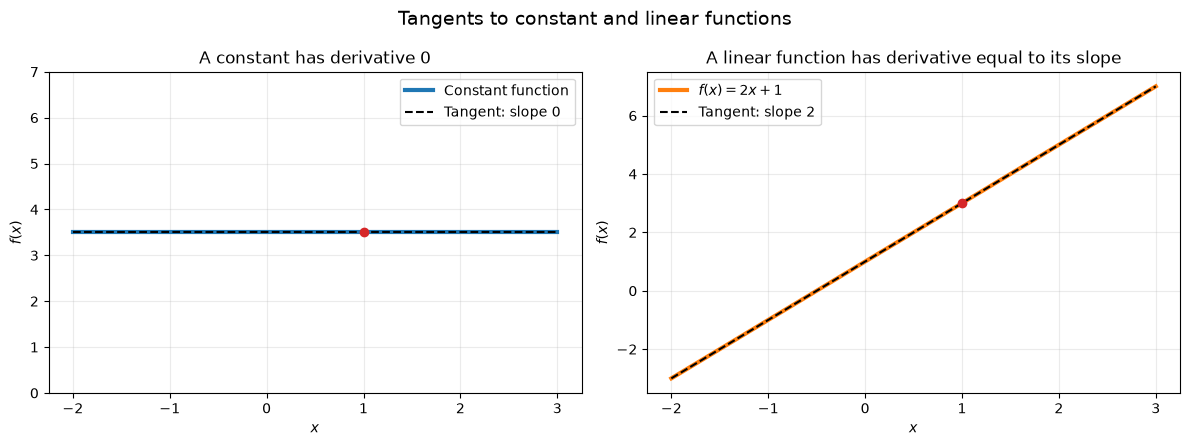

In [6]:
line_inputs: np.ndarray = np.linspace(-2.0, 3.0, 200)
constant_outputs: np.ndarray = np.full_like(line_inputs, 3.5)
linear_outputs: np.ndarray = 2.0 * line_inputs + 1.0
point_input: float = 1.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(line_inputs, constant_outputs, color="tab:blue", linewidth=3,
             label="Constant function")
axes[0].plot(line_inputs, constant_outputs, color="black", linestyle="--",
             label="Tangent: slope 0")
axes[0].scatter([point_input], [3.5], color="tab:red", zorder=3)
axes[0].set(
    xlabel="$x$",
    ylabel="$f(x)$",
    title="A constant has derivative 0",
    ylim=(0, 7),
)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(line_inputs, linear_outputs, color="tab:orange", linewidth=3,
             label="$f(x)=2x+1$")
axes[1].plot(line_inputs, linear_outputs, color="black", linestyle="--",
             label="Tangent: slope 2")
axes[1].scatter([point_input], [3.0], color="tab:red", zorder=3)
axes[1].set(
    xlabel="$x$",
    ylabel="$f(x)$",
    title="A linear function has derivative equal to its slope",
)
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.suptitle("Tangents to constant and linear functions", fontsize=14)
fig.tight_layout()
plt.show()

### Summary

| Function | Graph | Derivative |
|---|---|---|
| $f(x)=c$ | Horizontal line | $f'(x)=0$ |
| $f(x)=ax+b$ | Line with slope $a$ | $f'(x)=a$ |

The intercept $b$ moves a line up or down but does not change its slope. This is why it does not appear in the derivative.

## Video 7 — The derivative of a quadratic

After constants and lines, consider a slightly more complicated function: a quadratic.

The simplest quadratic is

$$
f(x)=x^2.
$$

Its graph is a parabola. To the left of the vertical axis, its tangent slopes are negative. At the bottom, the tangent is horizontal. To the right, its tangent slopes are positive.

### Approximating the slope at $x=1$

At $x=1$,

$$
f(1)=1^2=1.
$$

Choose a second point a horizontal distance $\Delta x$ to the right. The vertical change is

$$
\Delta f
=
f(1+\Delta x)-f(1)
=
(1+\Delta x)^2-1^2.
$$

The slope of the secant line is

$$
\frac{\Delta f}{\Delta x}.
$$

Making $\Delta x$ smaller moves the second point toward $x=1$, so the secant slope approaches the tangent slope.

### Successively smaller intervals

| $\Delta x$ | $\Delta f=(1+\Delta x)^2-1$ | Secant slope $\frac{\Delta f}{\Delta x}$ |
|---:|---:|---:|
| $1$ | $3$ | $3$ |
| $\frac{1}{2}$ | $1.25$ | $2.5$ |
| $\frac{1}{4}$ | $0.5625$ | $2.25$ |
| $\frac{1}{8}$ | $0.265625$ | $2.125$ |
| $\frac{1}{16}$ | $0.12890625$ | $2.0625$ |
| $\frac{1}{1000}$ | $0.002001$ | $2.001$ |

The slopes approach $2$. Therefore, the tangent slope—and the derivative—at $x=1$ is $2$.

### Secants approaching the tangent

The left plot shows how tangent slopes change across the parabola. The right plot fixes the point $x=1$ and moves the second point closer, just as in the calculation above.

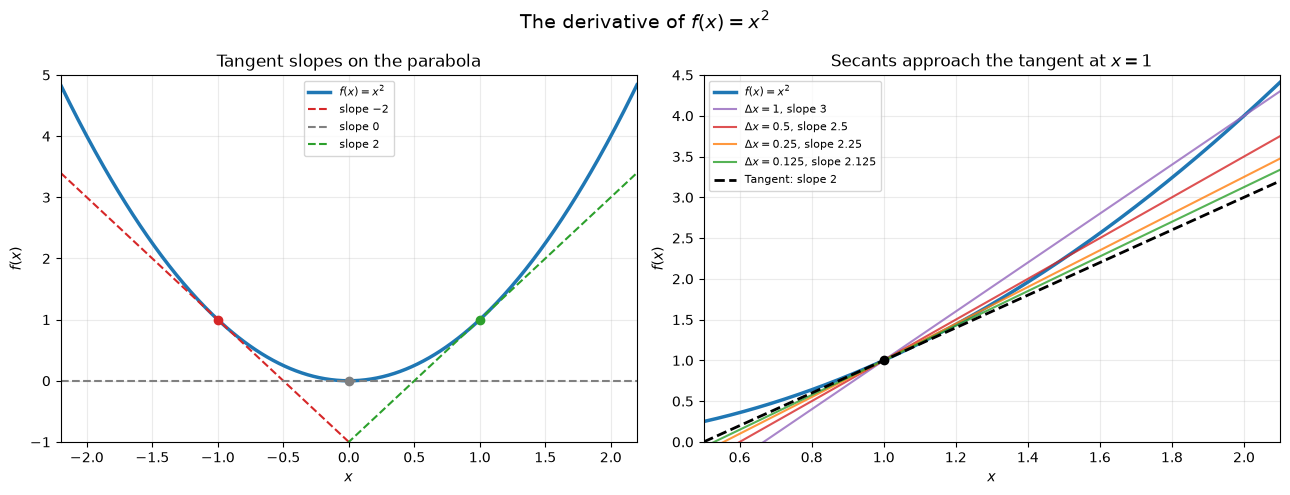

In [7]:
quadratic_inputs: np.ndarray = np.linspace(-2.2, 2.2, 400)
quadratic_outputs: np.ndarray = quadratic_inputs**2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(quadratic_inputs, quadratic_outputs, color="tab:blue", linewidth=2.5,
             label="$f(x)=x^2$")
tangent_points: list[tuple[float, str]] = [
    (-1.0, "slope $-2$"),
    (0.0, "slope $0$"),
    (1.0, "slope $2$"),
]
tangent_colors: list[str] = ["tab:red", "gray", "tab:green"]
for (point, label), color in zip(tangent_points, tangent_colors, strict=True):
    tangent_slope: float = 2.0 * point
    tangent_outputs: np.ndarray = point**2 + tangent_slope * (quadratic_inputs - point)
    axes[0].plot(quadratic_inputs, tangent_outputs, color=color, linestyle="--", label=label)
    axes[0].scatter([point], [point**2], color=color, zorder=3)
axes[0].set(
    xlabel="$x$",
    ylabel="$f(x)$",
    title="Tangent slopes on the parabola",
    xlim=(-2.2, 2.2),
    ylim=(-1, 5),
)
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

focus_inputs: np.ndarray = np.linspace(0.5, 2.1, 300)
axes[1].plot(focus_inputs, focus_inputs**2, color="tab:blue", linewidth=2.5,
             label="$f(x)=x^2$")
base_input: float = 1.0
base_output: float = 1.0
secant_intervals: list[float] = [1.0, 0.5, 0.25, 0.125]
secant_colors: list[str] = ["tab:purple", "tab:red", "tab:orange", "tab:green"]
for interval, color in zip(secant_intervals, secant_colors, strict=True):
    second_input: float = base_input + interval
    second_output: float = second_input**2
    secant_slope: float = (second_output - base_output) / interval
    secant_outputs: np.ndarray = base_output + secant_slope * (focus_inputs - base_input)
    axes[1].plot(focus_inputs, secant_outputs, color=color, alpha=0.8,
                 label=rf"$\Delta x={interval:g}$, slope ${secant_slope:g}$")

exact_tangent_outputs: np.ndarray = base_output + 2.0 * (focus_inputs - base_input)
axes[1].plot(focus_inputs, exact_tangent_outputs, color="black", linestyle="--", linewidth=2,
             label="Tangent: slope $2$")
axes[1].scatter([base_input], [base_output], color="black", zorder=4)
axes[1].set(
    xlabel="$x$",
    ylabel="$f(x)$",
    title="Secants approach the tangent at $x=1$",
    xlim=(0.5, 2.1),
    ylim=(0, 4.5),
)
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

fig.suptitle("The derivative of $f(x)=x^2$", fontsize=14)
fig.tight_layout()
plt.show()

### Formal calculation

For a general input $x$, the change in the function is

$$
\Delta f
=
f(x+\Delta x)-f(x)
=
(x+\Delta x)^2-x^2.
$$

Divide by the horizontal change:

$$
\begin{aligned}
\frac{\Delta f}{\Delta x}
&=
\frac{(x+\Delta x)^2-x^2}{\Delta x} \\
&=
\frac{x^2+2x\Delta x+(\Delta x)^2-x^2}{\Delta x} \\
&=
\frac{2x\Delta x+\Delta x\cdot\Delta x}{\Delta x} \\
&=
\frac{\Delta x(2x+\Delta x)}{\Delta x} \\
&=
2x+\Delta x.
\end{aligned}
$$

Both numerator terms contain $\Delta x$, so it is factored out and cancelled. At this stage $\Delta x\ne 0$ because the two secant points are still distinct.

As $\Delta x$ approaches zero, the final $\Delta x$ term disappears:

$$
\begin{aligned}
f'(x)
&=
\lim_{\Delta x\to 0}\frac{\Delta f}{\Delta x} \\
&=
\lim_{\Delta x\to 0}(2x+\Delta x) \\
&=
2x.
\end{aligned}
$$

Therefore,

$$
\boxed{f(x)=x^2 \quad\Longrightarrow\quad f'(x)=2x.}
$$

### Interpretation

The formula $f'(x)=2x$ matches the shape of the parabola:

- if $x<0$, then $f'(x)<0$, so the graph slopes downward;
- if $x=0$, then $f'(x)=0$, so the tangent is horizontal;
- if $x>0$, then $f'(x)>0$, so the graph slopes upward;
- at $x=1$, $f'(1)=2$, matching the secant estimates.

## Video 8 — The derivative of a cubic

After lines and quadratics, consider the simplest cubic function:

$$
f(x)=x^3.
$$

As before, the derivative is found by letting a secant interval shrink toward zero:

$$
f'(x)=\lim_{\Delta x\to0}\frac{(x+\Delta x)^3-x^3}{\Delta x}.
$$

The secant slope approaches the slope of the tangent line.

### Approximating the slope at $x=0.5$

At $x=0.5$,

$$
f(0.5)=(0.5)^3=\frac18=0.125.
$$

> **Numerical note:** the spoken transcript appears to say “1.8,” but $\left(\frac12\right)^3$ is exactly $\frac18=0.125$.

Choose a second point at $0.5+\Delta x$. Then

$$
\Delta f=(0.5+\Delta x)^3-(0.5)^3
$$

and the secant slope is $\frac{\Delta f}{\Delta x}$.

### Successively smaller intervals

| $\Delta x$ | $\Delta f$ | Secant slope $\frac{\Delta f}{\Delta x}$ |
|---:|---:|---:|
| $1$ | $3.25$ | $3.25$ |
| $\frac12$ | $0.875$ | $1.75$ |
| $\frac14$ | $0.296875$ | $1.1875$ |
| $\frac18$ | $0.119140625$ | $0.953125$ |
| $\frac1{16}$ | $0.052978515625$ | $0.84765625$ |
| $\frac1{1000}$ | $0.000751501$ | $0.751501$ |

The course rounds some values in the narration. The slopes approach $0.75$, so

$$
f'(0.5)=0.75.
$$

This agrees with $3(0.5)^2=0.75$.

### Expanding the cube

For a general input $x$,

$$
\frac{\Delta f}{\Delta x}=\frac{(x+\Delta x)^3-x^3}{\Delta x}.
$$

Use the cube expansion

$$
(x+\Delta x)^3=x^3+3x^2\Delta x+3x(\Delta x)^2+(\Delta x)^3.
$$

Substitute it and cancel the positive and negative $x^3$ terms:

$$
\frac{\Delta f}{\Delta x}
=
\frac{3x^2\Delta x+3x(\Delta x)^2+(\Delta x)^3}{\Delta x}.
$$

### Factoring out $\Delta x$

Every numerator term contains one factor of $\Delta x$:

$$
3x^2\Delta x+3x(\Delta x)^2+(\Delta x)^3
=
\Delta x\left(3x^2+3x\Delta x+(\Delta x)^2\right).
$$

Therefore,

$$
\begin{aligned}
\frac{\Delta f}{\Delta x}
&=
\frac{\Delta x\left(3x^2+3x\Delta x+(\Delta x)^2\right)}{\Delta x} \\
&=
3x^2+3x\Delta x+(\Delta x)^2.
\end{aligned}
$$

The common factor cancels while $\Delta x\ne0$, before taking the limit.

### Taking the limit

As $\Delta x$ approaches zero, every remaining term containing $\Delta x$ approaches zero:

$$
\begin{aligned}
f'(x)
&=
\lim_{\Delta x\to0}\left(3x^2+3x\Delta x+(\Delta x)^2\right) \\
&=
3x^2.
\end{aligned}
$$

Therefore,

$$
\boxed{f(x)=x^3 \quad\Longrightarrow\quad f'(x)=3x^2.}
$$

At $x=0.5$, this gives $f'(0.5)=3(0.5)^2=0.75$, matching the secant estimates.

## Video 9 — The reciprocal function and the power rule

After lines and polynomial examples, consider the reciprocal function

$$
f(x)=\frac1x=x^{-1}, \qquad x\ne0.
$$

Its graph is a hyperbola with two branches. The function is not defined at $x=0$.

As before, start with the secant slope

$$
\frac{\Delta f}{\Delta x}
=
\frac{\frac1{x+\Delta x}-\frac1x}{\Delta x}
$$

and let $\Delta x$ approach zero to obtain the tangent slope.

### Approximating the derivative at $x=1$

At $x=1$,

$$
f(1)=1.
$$

For a second point at $1+\Delta x$, the vertical change is

$$
\Delta f=\frac1{1+\Delta x}-1.
$$

The resulting secant slopes are:

| $\Delta x$ | $\Delta f$ | Secant slope $\frac{\Delta f}{\Delta x}$ |
|---:|---:|---:|
| $1$ | $-0.5$ | $-0.5$ |
| $\frac12$ | $-\frac13$ | $-\frac23\approx-0.667$ |
| $\frac14$ | $-0.2$ | $-0.8$ |
| $\frac18$ | $-\frac19$ | $-\frac89\approx-0.889$ |
| $\frac1{16}$ | $-\frac1{17}$ | $-\frac{16}{17}\approx-0.941$ |
| $\frac1{1000}$ | $-\frac1{1001}$ | $-\frac{1000}{1001}\approx-0.999$ |

The slopes approach $-1$. Therefore,

$$
f'(1)=-1.
$$

### Hyperbola and secant lines

The left plot shows the two branches of $f(x)=\frac1x$ and tangent lines at $x=-1$ and $x=1$. Both tangent slopes are negative. The right plot shows secant lines approaching the tangent at $x=1$.

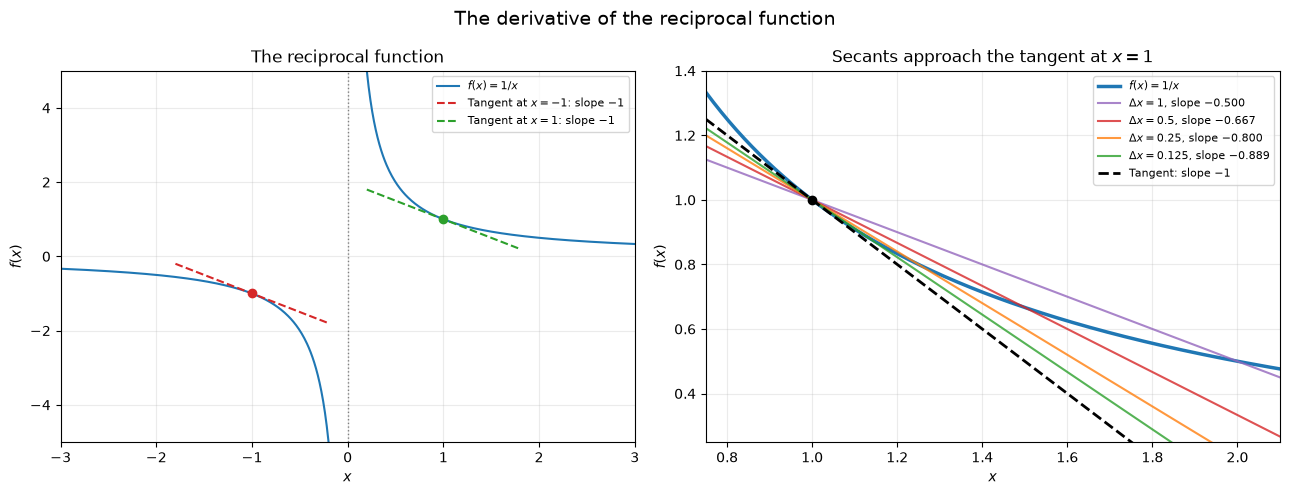

In [8]:
negative_inputs: np.ndarray = np.linspace(-3.0, -0.2, 300)
positive_inputs: np.ndarray = np.linspace(0.2, 3.0, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(negative_inputs, 1.0 / negative_inputs, color="tab:blue")
axes[0].plot(positive_inputs, 1.0 / positive_inputs, color="tab:blue", label="$f(x)=1/x$")
for point, color in [(-1.0, "tab:red"), (1.0, "tab:green")]:
    tangent_slope: float = -1.0 / point**2
    tangent_inputs: np.ndarray = np.linspace(point - 0.8, point + 0.8, 100)
    tangent_outputs: np.ndarray = 1.0 / point + tangent_slope * (tangent_inputs - point)
    axes[0].plot(tangent_inputs, tangent_outputs, color=color, linestyle="--",
                 label=rf"Tangent at $x={point:g}$: slope $-1$")
    axes[0].scatter([point], [1.0 / point], color=color, zorder=3)
axes[0].axvline(0, color="gray", linestyle=":", linewidth=1)
axes[0].set(
    xlabel="$x$",
    ylabel="$f(x)$",
    title="The reciprocal function",
    xlim=(-3, 3),
    ylim=(-5, 5),
)
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

focus_inputs: np.ndarray = np.linspace(0.75, 2.1, 300)
axes[1].plot(focus_inputs, 1.0 / focus_inputs, color="tab:blue", linewidth=2.5,
             label="$f(x)=1/x$")
base_input: float = 1.0
base_output: float = 1.0
reciprocal_intervals: list[float] = [1.0, 0.5, 0.25, 0.125]
reciprocal_colors: list[str] = ["tab:purple", "tab:red", "tab:orange", "tab:green"]
for interval, color in zip(reciprocal_intervals, reciprocal_colors, strict=True):
    second_input: float = base_input + interval
    second_output: float = 1.0 / second_input
    secant_slope: float = (second_output - base_output) / interval
    secant_outputs: np.ndarray = base_output + secant_slope * (focus_inputs - base_input)
    axes[1].plot(focus_inputs, secant_outputs, color=color, alpha=0.8,
                 label=rf"$\Delta x={interval:g}$, slope ${secant_slope:.3f}$")

reciprocal_tangent: np.ndarray = base_output - (focus_inputs - base_input)
axes[1].plot(focus_inputs, reciprocal_tangent, color="black", linestyle="--", linewidth=2,
             label="Tangent: slope $-1$")
axes[1].scatter([base_input], [base_output], color="black", zorder=4)
axes[1].set(
    xlabel="$x$",
    ylabel="$f(x)$",
    title="Secants approach the tangent at $x=1$",
    xlim=(0.75, 2.1),
    ylim=(0.25, 1.4),
)
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

fig.suptitle("The derivative of the reciprocal function", fontsize=14)
fig.tight_layout()
plt.show()

### Combining the fractions

For a general input $x$,

$$
\frac{\Delta f}{\Delta x}
=
\frac{\frac1{x+\Delta x}-\frac1x}{\Delta x}.
$$

Before combining these terms, recall the **common-denominator rule for subtracting fractions**. For nonzero denominators $b$ and $d$,

$$
\frac ab-\frac cd=\frac{ad-bc}{bd}.
$$

This rule comes from rewriting both fractions with the same denominator $bd$:

$$
\frac ab=\frac{ad}{bd}
\qquad\text{and}\qquad
\frac cd=\frac{bc}{bd}.
$$

In this derivative calculation, use

$$
a=1,\quad b=x+\Delta x,\quad c=1,\quad d=x.
$$

Substituting those values into the rule shows every step:

$$
\begin{aligned}
\frac1{x+\Delta x}-\frac1x
&=
\frac{(1)(x)-(x+\Delta x)(1)}{(x+\Delta x)x} \\
&=
\frac{x-(x+\Delta x)}{x(x+\Delta x)} \\
&=
\frac{x-x-\Delta x}{x(x+\Delta x)} \\
&=
\frac{-\Delta x}{x(x+\Delta x)}.
\end{aligned}
$$

Substitute this back into the difference quotient:

$$
\frac{\Delta f}{\Delta x}
=
\frac{-\Delta x}{x(x+\Delta x)}\cdot\frac1{\Delta x}.
$$

Cancel the common $\Delta x$ while $\Delta x\ne0$:

$$
\frac{\Delta f}{\Delta x}
=
-\frac1{x(x+\Delta x)}.
$$

### Taking the limit

As $\Delta x$ approaches zero,

$$
\begin{aligned}
f'(x)
&=
\lim_{\Delta x\to0}\left(-\frac1{x(x+\Delta x)}\right) \\
&=
-\frac1{x^2} \\
&=
-x^{-2}.
\end{aligned}
$$

Therefore,

$$
\boxed{f(x)=\frac1x=x^{-1}\quad\Longrightarrow\quad f'(x)=-\frac1{x^2}=-x^{-2}.}
$$

At $x=1$, this gives $f'(1)=-1$, matching the secant estimates.

### Recognizing the power rule

The derivatives calculated so far follow one pattern:

| Function | Derivative |
|---|---|
| $x^2$ | $2x^{2-1}=2x$ |
| $x^3$ | $3x^{3-1}=3x^2$ |
| $x^{-1}$ | $-1x^{-1-1}=-x^{-2}$ |

The exponent moves in front as a multiplication factor, and the exponent decreases by one:

$$
\boxed{\frac{d}{dx}x^n=nx^{n-1}.}
$$

This is the **power rule**, used wherever the power and derivative are defined.

For example,

$$
\frac{d}{dx}x^{100}=100x^{99}
$$

and

$$
\frac{d}{dx}x^{-100}=-100x^{-101}.
$$